<a href="https://colab.research.google.com/github/seungah-lab/Intelligence-powered-epidemiology/blob/main/Week%204/PEACH_cohort_DNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 머신러닝 관련
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
import os

In [6]:
# 1) 데이터 불러오기: 같은 폴더에 'peach_2nd_ano.csv'가 있어야 합니다.
#    파일 인코딩 문제가 있을 수 있으므로 utf-8로 먼저 시도하고 실패하면 cp949로 재시도합니다.
csv_path = "https://github.com/seungah-lab/Intelligence-powered-epidemiology/raw/refs/heads/main/Week%204/peach_2nd_ano.csv"

try:
    df = pd.read_csv(csv_path, encoding="utf-8")
except Exception:
    df = pd.read_csv(csv_path, encoding="cp949", engine="python")

(182, 56)
   Urine_ID  1_height  2_weight  3_waist  4_hip  5_self_rated_health  \
0       2.0     149.8      53.6     77.0   92.5                  3.0   
1       4.0     148.0      34.5     62.0   77.8                  4.0   
2       5.0     149.0      53.6     80.0   91.5                  2.0   
3       6.0     146.2      33.4     60.8   76.5                  4.0   
4      10.0     164.0      49.0     63.0   88.0                  4.0   

   6_moderate_activity  7_walking_hrs  8_strong_activity  9_gym_class  ...  \
0                  6.0            1.0                6.0          4.0  ...   
1                  4.0            3.0                4.0          3.0  ...   
2                  2.0            1.0                4.0          3.0  ...   
3                  6.0           10.0                6.0          3.0  ...   
4                  4.0            1.0                3.0          3.0  ...   

   smartphone_usealways  smartphone_conflict  smartphone_interrupted  \
0               

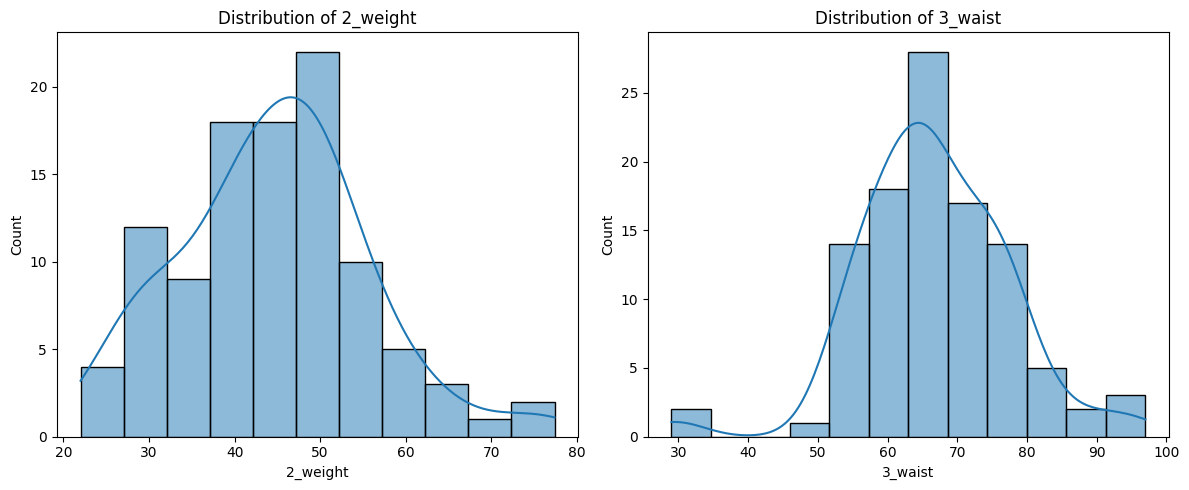

In [16]:
# 2) 기본 확인: 상위 5개, 컬럼 정보, 결측치 개수 확인
print(df.shape)   # (182, 54)  줄, 열 수
print(df.head(5))  #    - head() : 데이터 구조를 빠르게 파악
print(df.info())  #    - info() : 각 컬럼 타입과 non-null 개수 확인
print(df.isna().sum())  #    - isna().sum() : 컬럼별 결측치 개수 확인

# 분포 확인: '2_weight'와 '3_waist'
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['2_weight'].dropna(), kde=True)
plt.title('Distribution of 2_weight')

plt.subplot(1, 2, 2)
sns.histplot(df['3_waist'].dropna(), kde=True)
plt.title('Distribution of 3_waist')
plt.tight_layout()
plt.show()

In [11]:
# 3) 컬럼명 정리(공백/앞뒤 공백 제거)
df.columns = df.columns.str.strip()

In [13]:
# 4) 숫자형으로 변환 가능한 컬럼은 숫자형으로 변환
#    - errors='coerce'로 숫자로 변환 불가능한 값은 NaN으로 변환
numeric_cols = []
for col in df.columns:
    # Urine_ID는 아이디로 남겨둡니다.
    if col == 'Urine_ID':
        continue
    # 시도: float 변환 가능한지
    coerced = pd.to_numeric(df[col], errors='coerce')
    # 변환 후 숫자가 하나라도 존재하면 숫자형으로 간주
    if coerced.notna().sum() > 0:
        df[col] = coerced
        numeric_cols.append(col)
    else:
        # 숫자로 변환 불가하면 그대로 두고 문자형 컬럼으로 남김
        pass

print(numeric_cols)  # 숫자형으로 변환된 컬럼 목록

['1_height', '2_weight', '3_waist', '4_hip', '5_self_rated_health', '6_moderate_activity', '7_walking_hrs', '8_strong_activity', '9_gym_class', '10_perfume', '11_hair_product', '12_makeup', '12_1_makeup_name', '12_2_makeup_name', '12_3_makeup_name', '12_4_makeup_name', '13_armpit_hair', '14_pubic_hair', '15_breast_budding', '16_age_menarche', '17_mens_product', '17_2_mens_product', '17_3_mens_product', '18_dysmenorrhea', '19_stress', '20_bedtime_hr', '20_bedtime_min', '21_wakeup_hr', '21_wakeup_min', '22_screen_hrs', '22_screen_mins', '23_screen_hrs_wkends', '23_screen_mins_wkends', 'last_height_children', 'last_weight_children']


In [14]:
# 5) 허리-엉덩이 비율(waist-hip ratio, whr) 계산
#    - 원본 컬럼명에 따라 '3_waist', '4_hip'를 사용합니다.
if '3_waist' not in df.columns or '4_hip' not in df.columns:
    raise KeyError("CSV에 '3_waist' 또는 '4_hip' 컬럼이 없습니다. 컬럼명이 다른지 확인해주세요.")

# whr 계산 (단위가 동일하다고 가정)
df['whr'] = df['3_waist'] / df['4_hip']

In [15]:
# 6) 목표변수 생성: whr > 0.875 인 경우를 1, 아니면 0으로 설정
threshold = 0.875
df['whr_gt_0875'] = (df['whr'] > threshold).astype(int)

In [17]:
# 7) whr 분포와 임계값에 따른 그룹 수 확인
print("\n===== whr 요약 통계 =====")
print(df['whr'].describe())
print("\n임계값", threshold, "보다 큰 샘플 수:")
print(df['whr_gt_0875'].value_counts(dropna=False))


===== whr 요약 통계 =====
count    104.000000
mean       0.791348
std        0.083630
min        0.400000
25%        0.750675
50%        0.795060
75%        0.830059
max        0.968421
Name: whr, dtype: float64

임계값 0.875 보다 큰 샘플 수:
whr_gt_0875
0    169
1     13
Name: count, dtype: int64


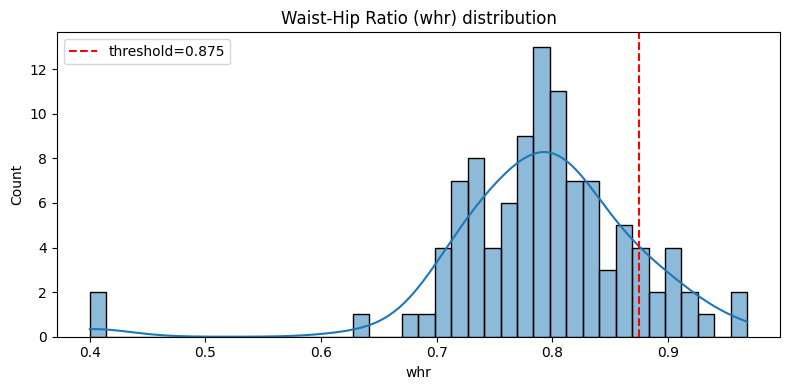

In [18]:
# 8) 간단한 시각화: whr 히스토그램 + 임계값 표시
plt.figure(figsize=(8,4))
sns.histplot(df['whr'].dropna(), bins=40, kde=True)
plt.axvline(threshold, color='red', linestyle='--', label=f"threshold={threshold}")
plt.title("Waist-Hip Ratio (whr) distribution")
plt.legend()
plt.tight_layout()
plt.show()

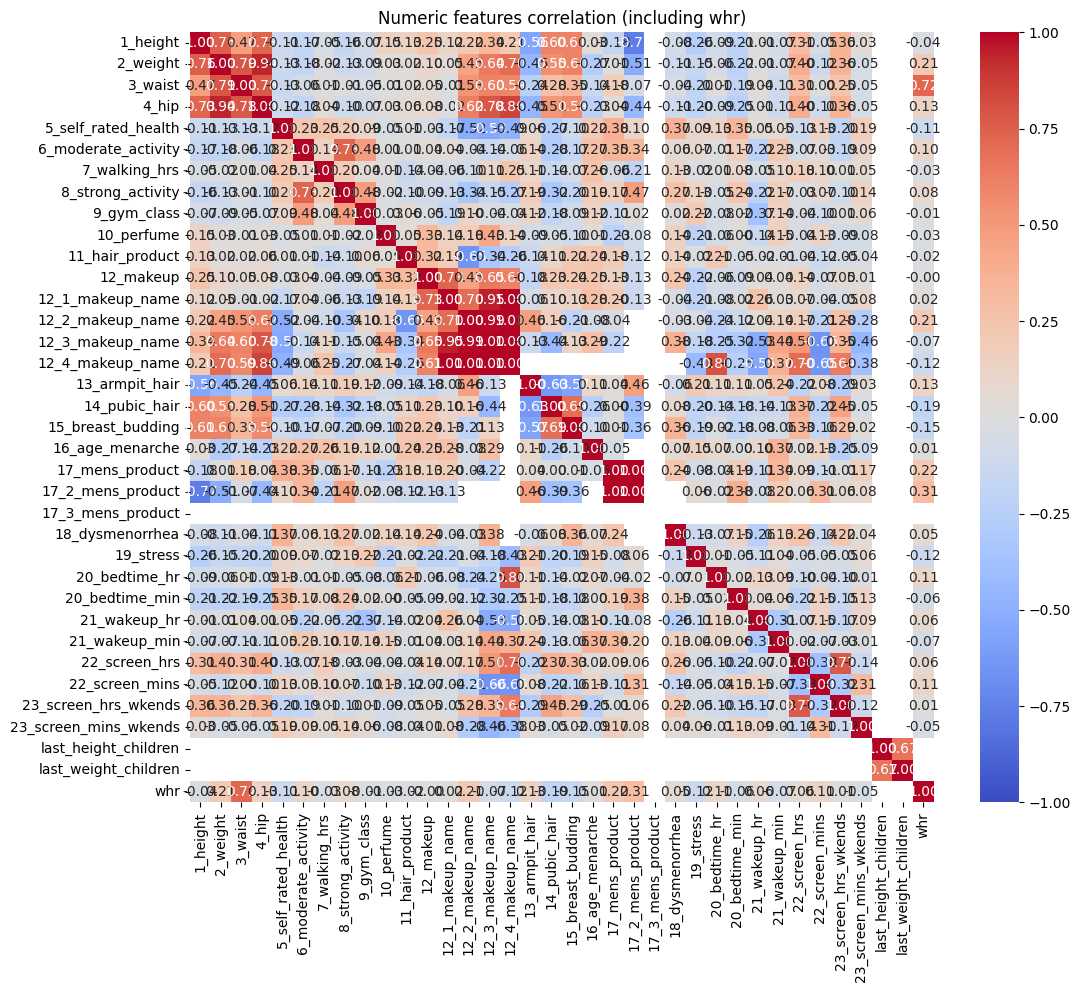

In [19]:
# 9) 상관관계 히트맵 (숫자 컬럼만 사용)
plt.figure(figsize=(12,10))
corr = df[numeric_cols + ['whr']].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Numeric features correlation (including whr)")
plt.show()

In [48]:
# 10) 특징 선택(간단한 베이스라인)
#     - 여기서는 대표적인 인체계측값과 연관 있을 법한 컬럼들을 사용합니다.
#     - 최소한 '1_height', '2_weight', '3_waist', '4_hip', '16_age_menarche'가 있다면 사용
candidate_features = []
for c in ['1_height','2_weight','5_self_rated_health','7_walking_hrs', '21_wakeup_hr','22_screen_hrs']:
    if c in df.columns:
        candidate_features.append(c)

# 만약 나열된 후보가 너무 적으면, 숫자형 컬럼 중 결측치 비율이 낮은 상위 6개를 사용
if len(candidate_features) < 3:
    num_nonnull = df[numeric_cols].notnull().mean().sort_values(ascending=False)
    good_cols = num_nonnull[num_nonnull > 0.6].index.tolist()  # non-null 비율 > 60%
    candidate_features = good_cols[:6]  # 상위 6개 선택

In [49]:
# 11) 모델을 위해 사용할 데이터프레임 준비
model_df = df[candidate_features + ['whr_gt_0875', 'whr']].copy()
print(model_df.shape)
print(model_df.head(5))

(182, 8)
   1_height  2_weight  5_self_rated_health  7_walking_hrs  21_wakeup_hr  \
0     149.8      53.6                  3.0            1.0           7.0   
1     148.0      34.5                  4.0            3.0           7.0   
2     149.0      53.6                  2.0            1.0           7.0   
3     146.2      33.4                  4.0           10.0           7.0   
4     164.0      49.0                  4.0            1.0           7.0   

   22_screen_hrs  whr_gt_0875       whr  
0            3.0            0  0.832432  
1            3.0            0  0.796915  
2            2.0            0  0.874317  
3            1.0            0  0.794771  
4            1.0            0  0.715909  


In [50]:
# 12) 결측치 처리: 간단히 해당 행 제거 (간단한 실습 목적) - 대개는 결측치가 10% 넘으면 imputation을 하든가 feature 조정이 필요
before_len = len(model_df)
model_df = model_df.dropna(subset=candidate_features + ['whr_gt_0875'])
after_len = len(model_df)
print(f"\n결측치 제거 전 샘플 수: {before_len}, 제거 후: {after_len}")


결측치 제거 전 샘플 수: 182, 제거 후: 100


In [51]:
# 13) 특징(X)과 타깃(y) 분리
X = model_df[candidate_features].values
y = model_df['whr_gt_0875'].values

In [52]:
# 14) 학습/검증 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [55]:
# 15) 스케일링: 표준화(평균0, 표준편차1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [56]:
# 16) 신경망 모델 정의 (Keras)
#     - candidate_features 수에 따라 input_dim이 겨ᄅ정대마
#     - Dense(32)나는 32개의 뉴런을 가진 은니층을 므ᄅ미하며, ReLU 허숑해 하ᄆ수를 사ᄋ용하먀(으ᄆ수느는 0으로, 야ᄆ수느는 그대로 툥가시께 하ᄀ스ᄑ 소ᄀ도를 노ᄑ이고 기울기 소실 문재를 바ᄃ지)
model = Sequential([
    Dense(32, input_dim=X_train_scaled.shape[1], activation='relu', name='Dense_1'),   # Dense_1 (32개 노드): (입력 6개 × 가중치 32개) + 바이어스 32개 = 224개
    Dense(16, activation='relu', name='Dense_2'),   # (입력 32개 × 가중치 16개) + 바이어스 16개 = 528개
    Dense(1, activation='sigmoid', name='Output')    # (입력 16개 × 가중치 1개) + 바이어스 1개 = 17개
])
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Dense_1 (Dense)                 │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:
# 17) 학습: 조기종료(EarlyStopping)를 적용해 과적합 방지
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
history = model.fit(X_train_scaled, y_train, validation_split=0.15, epochs=100, batch_size=8, callbacks=[es], verbose=2)

Epoch 1/100
9/9 - 6s - 615ms/step - accuracy: 0.5588 - loss: 0.7101 - val_accuracy: 0.4167 - val_loss: 0.7408
Epoch 2/100
9/9 - 0s - 29ms/step - accuracy: 0.7059 - loss: 0.6107 - val_accuracy: 0.5000 - val_loss: 0.6586
Epoch 3/100
9/9 - 0s - 27ms/step - accuracy: 0.8529 - loss: 0.5341 - val_accuracy: 0.6667 - val_loss: 0.6078
Epoch 4/100
9/9 - 0s - 26ms/step - accuracy: 0.8971 - loss: 0.4747 - val_accuracy: 0.7500 - val_loss: 0.5765
Epoch 5/100
9/9 - 0s - 24ms/step - accuracy: 0.8971 - loss: 0.4290 - val_accuracy: 0.7500 - val_loss: 0.5561
Epoch 6/100
9/9 - 0s - 49ms/step - accuracy: 0.8971 - loss: 0.3911 - val_accuracy: 0.7500 - val_loss: 0.5394
Epoch 7/100
9/9 - 0s - 40ms/step - accuracy: 0.8971 - loss: 0.3607 - val_accuracy: 0.7500 - val_loss: 0.5323
Epoch 8/100
9/9 - 0s - 23ms/step - accuracy: 0.8971 - loss: 0.3368 - val_accuracy: 0.7500 - val_loss: 0.5315
Epoch 9/100
9/9 - 0s - 39ms/step - accuracy: 0.8971 - loss: 0.3164 - val_accuracy: 0.7500 - val_loss: 0.5371
Epoch 10/100
9/9 -

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
Accuracy: 0.9

Classification report:
               precision    recall  f1-score   support

           0       0.90      1.00      0.95        18
           1       0.00      0.00      0.00         2

    accuracy                           0.90        20
   macro avg       0.45      0.50      0.47        20
weighted avg       0.81      0.90      0.85        20



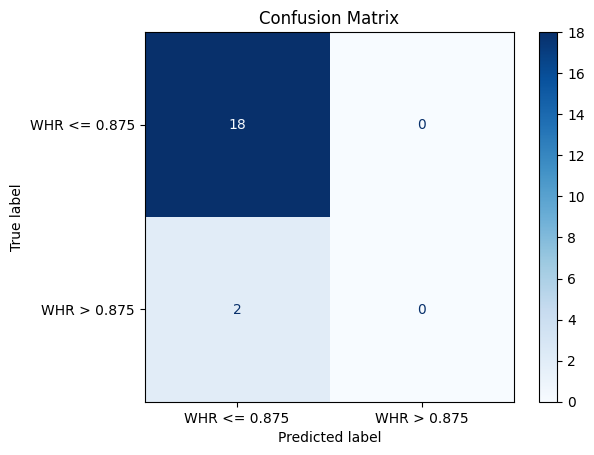

In [60]:
# 18) 검증
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_prob = model.predict(X_test_scaled).ravel()  # whr>0.875일 확률
y_pred = (y_pred_prob >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['WHR <= 0.875', 'WHR > 0.875'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()